# 03. Sample QC（Quality Control） and exploratory normalization

このノートブックは、count matrixができた後に、サンプル全体の関係を見る段階である。

**このノートブックの役割**

- サンプルごとのlibrary sizeと検出遺伝子数を確認する。
- logCPMを使ってPCAとsample correlationを作り、replicateや群のまとまりを見る。
- 外れ値候補や、以降の差次的発現解析で注意すべきサンプル構造を見つける。

**入力**

- `results/counts/gene_counts.tsv`（行=gene、列=sampleのraw count matrix）
- `metadata/samples.tsv`（サンプルID、群、replicateを対応づける表）

**出力**

- `results/sample_qc/library_size.tsv`（サンプルごとの総read countと検出遺伝子数）
- `results/sample_qc/pca_logcpm.tsv`（PCA座標とサンプル情報をまとめた表）
- `results/sample_qc/*.png`（library size、PCA、sample correlation、高発現遺伝子の確認図）

**次に進む条件**

- 大きな外れ値がない、または外れ値の扱いを決めた。
- 群間差よりbatchや個体差が支配的でないかを確認した。


### コマンドライン実行について

このノートブックでは、FastQC、STAR、Salmon、Rscriptのような外部CLIは実行しない。入力済みのcount matrixをPythonで読み込み、QC表と図を作る段階なので、追加で説明すべきコマンドライン引数はない。


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

PROJECT_DIR = Path("/Users/yusuke_tateishi/Documents/RNA_seq").resolve()
CONFIG = json.loads((PROJECT_DIR / "config" / "analysis_config.json").read_text(encoding="utf-8"))
SAMPLES = pd.read_csv(PROJECT_DIR / CONFIG["samples_path"], sep="\t")
COUNTS_PATH = PROJECT_DIR / CONFIG["differential_expression"]["count_matrix_path"]
SAMPLE_QC_DIR = PROJECT_DIR / "results" / "sample_qc"
SAMPLE_QC_DIR.mkdir(parents=True, exist_ok=True)

if not COUNTS_PATH.exists():
    raise FileNotFoundError(f"Count matrix not found: {COUNTS_PATH}. Run notebook 02 first.")

counts = pd.read_csv(COUNTS_PATH, sep="\t")
counts = counts.set_index("gene_id")
counts = counts[SAMPLES["sample_id"]]
counts.head()


,NAC_S2_2h_1,NAC_S2_2h_2,NAC_S2_2h_3,Non_1,Non_2,Non_3,Oxi_2h_1,Oxi_2h_2,Oxi_2h_3
gene_id,,,,,,,,,
ENSG00000000003.17,1,0,1,1,1,3,0,0,3
ENSG00000000005.6,0,0,0,0,0,0,0,0,0
ENSG00000000419.15,838,720,738,753,750,609,688,833,731
ENSG00000000457.15,242,232,267,204,247,214,199,222,215
ENSG00000000460.18,453,341,400,369,413,318,294,313,294


## library sizeと検出遺伝子数

library sizeは、各サンプルの総countである。検出遺伝子数は、countが1以上あるgene数である。


In [2]:
sample_qc = pd.DataFrame(
    {
        "sample_id": counts.columns,
        "library_size": counts.sum(axis=0).values,
        "detected_genes": (counts > 0).sum(axis=0).values,
    }
).merge(SAMPLES[["sample_id", "condition", "replicate"]], on="sample_id", how="left")

sample_qc.to_csv(SAMPLE_QC_DIR / "library_size.tsv", sep="\t", index=False)
sample_qc


,sample_id,library_size,detected_genes,condition,replicate
0,NAC_S2_2h_1,11454066,24486,NAC_S2_2h,1
1,NAC_S2_2h_2,9441992,23974,NAC_S2_2h,2
2,NAC_S2_2h_3,10762853,24213,NAC_S2_2h,3
3,Non_1,11083193,23687,Non,1
4,Non_2,11676441,23786,Non,2
5,Non_3,9646290,23128,Non,3
6,Oxi_2h_1,10423816,22980,Oxi_2h,1
7,Oxi_2h_2,11354207,23348,Oxi_2h,2
8,Oxi_2h_3,10040931,23333,Oxi_2h,3


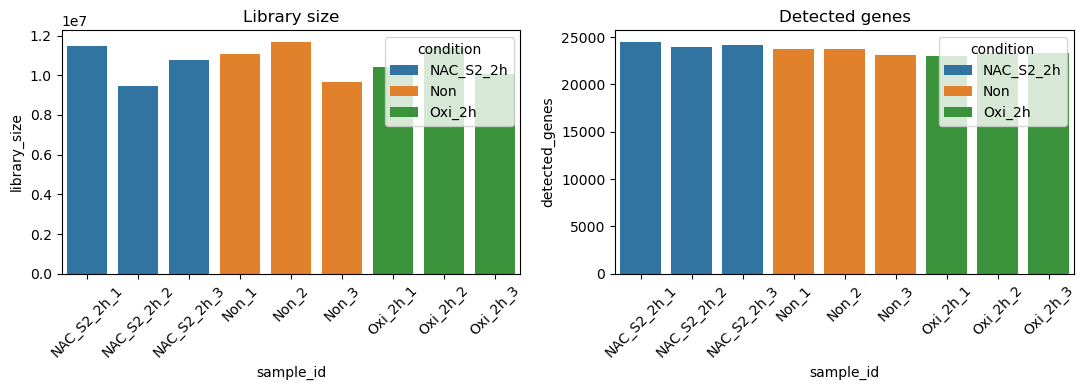

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=sample_qc, x="sample_id", y="library_size", hue="condition", ax=axes[0])
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Library size")
sns.barplot(data=sample_qc, x="sample_id", y="detected_genes", hue="condition", ax=axes[1])
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Detected genes")
plt.tight_layout()
plt.savefig(SAMPLE_QC_DIR / "library_size_detected_genes.png", dpi=160)
plt.show()


## logCPMを作る

PCAや相関を見るために、countを `log2(CPM + 1)` に変換する。

CPMは counts per million である。

`CPM_gs = count_gs / library_size_s * 1,000,000`

これは探索的可視化用である。DESeq2の統計検定そのものは次のノートブックで行う。


In [4]:
library_sizes = counts.sum(axis=0)
cpm = counts.divide(library_sizes, axis=1) * 1_000_000
log_cpm = np.log2(cpm + 1)
log_cpm.head()


,NAC_S2_2h_1,NAC_S2_2h_2,NAC_S2_2h_3,Non_1,Non_2,Non_3,Oxi_2h_1,Oxi_2h_2,Oxi_2h_3
gene_id,,,,,,,,,
ENSG00000000003.17,0.120757,0.000000,0.128177,0.124628,0.118549,0.390668,0.000000,0.000000,0.377154
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.15,6.212604,6.271558,6.120376,6.107284,6.027506,6.002997,6.066147,6.216549,6.205588
ENSG00000000457.15,4.467793,4.676442,4.689721,4.278449,4.469476,4.535101,4.328470,4.361223,4.486222
ENSG00000000460.18,5.341604,5.213941,5.254173,5.099870,5.184692,5.086021,4.868126,4.836271,4.920301


## PCA（Principal Component Analysis）

PCAは、サンプル間の大きな違いを2次元に圧縮して見る方法である。同じ群のreplicateが近くに集まるかを見る。


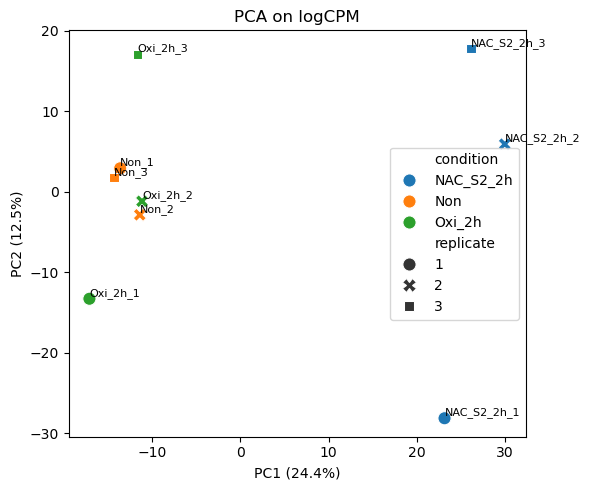

In [5]:
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(log_cpm.T)
pca_df = pd.DataFrame(pca_scores, columns=["PC1", "PC2"])
pca_df["sample_id"] = log_cpm.columns
pca_df = pca_df.merge(SAMPLES[["sample_id", "condition", "replicate"]], on="sample_id", how="left")
pca_df.to_csv(SAMPLE_QC_DIR / "pca_logcpm.tsv", sep="\t", index=False)

explained = pca.explained_variance_ratio_ * 100
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="condition", style="replicate", s=90, ax=ax)
for _, row in pca_df.iterrows():
    ax.text(row["PC1"], row["PC2"], row["sample_id"], fontsize=8, ha="left", va="bottom")
ax.set_xlabel(f"PC1 ({explained[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}%)")
ax.set_title("PCA on logCPM")
plt.tight_layout()
plt.savefig(SAMPLE_QC_DIR / "pca_logcpm.png", dpi=160)
plt.show()


## sample correlation heatmap

サンプル間相関は、サンプル同士が全体としてどれくらい似ているかを見る。同じ群のreplicateで高い相関が期待される。


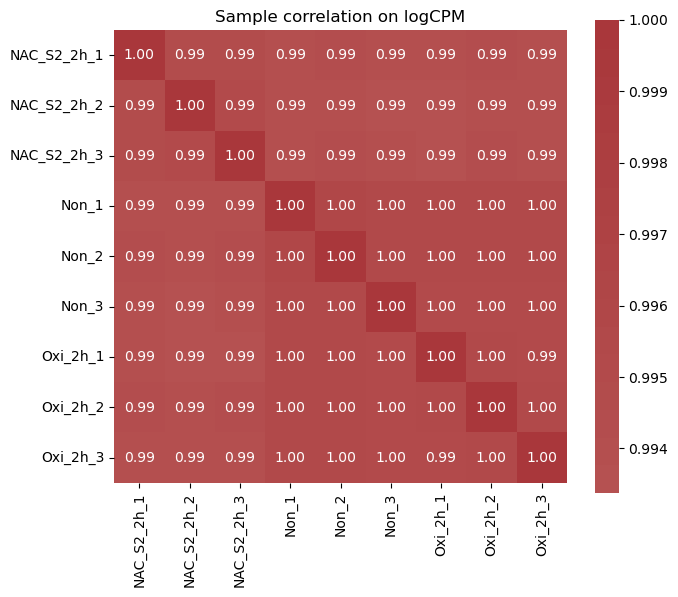

In [6]:
correlation = log_cpm.corr(method="pearson")
correlation.to_csv(SAMPLE_QC_DIR / "sample_correlation_logcpm.tsv", sep="\t")

plt.figure(figsize=(7, 6))
sns.heatmap(correlation, cmap="vlag", center=0.95, annot=True, fmt=".2f", square=True)
plt.title("Sample correlation on logCPM")
plt.tight_layout()
plt.savefig(SAMPLE_QC_DIR / "sample_correlation_logcpm.png", dpi=160)
plt.show()


## 高発現遺伝子を見る

高発現遺伝子はライブラリの構成に強く影響する。ミトコンドリア遺伝子、rRNA、ストレス応答遺伝子などが上位に出ることがある。


In [7]:
mean_counts = counts.mean(axis=1).sort_values(ascending=False)
top_genes = mean_counts.head(30).rename("mean_count").reset_index()
top_genes.to_csv(SAMPLE_QC_DIR / "top_mean_count_genes.tsv", sep="\t", index=False)
top_genes.head(20)


,gene_id,mean_count
0,ENSG00000156508.21,115037.888889
1,ENSG00000198804.2,69203.000000
2,ENSG00000111640.16,68915.444444
3,ENSG00000075624.18,54949.888889
4,ENSG00000070756.18,43060.666667
5,ENSG00000161016.19,42868.333333
6,ENSG00000167658.17,39091.555556
7,ENSG00000123416.16,37237.000000
8,ENSG00000198886.2,36033.333333
9,ENSG00000109971.15,35336.888889


**よくある間違い**

- count matrixができた直後に、PCAや相関を見ずにDESeq2へ進む。
- 外れ値らしきサンプルを見つけても、理由を調べずに機械的に削除する。

**小さい練習**

PCAで一番離れているサンプルがある場合、そのサンプルの `library_size` と `detected_genes` を見比べよう。
